<a href="https://colab.research.google.com/github/shivanshsingh-123/CODSOFT-INTERNSHIP/blob/main/iris_flower_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries Imported Successfully!

Dataset Overview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species Species_Name  
0        0       Setosa  
1        0       Setosa  
2        0       Setosa  
3        0       Setosa  
4        0       Setosa   

Generating Beautiful Visualizations... (Please wait a second)


<Figure size 1000x800 with 0 Axes>

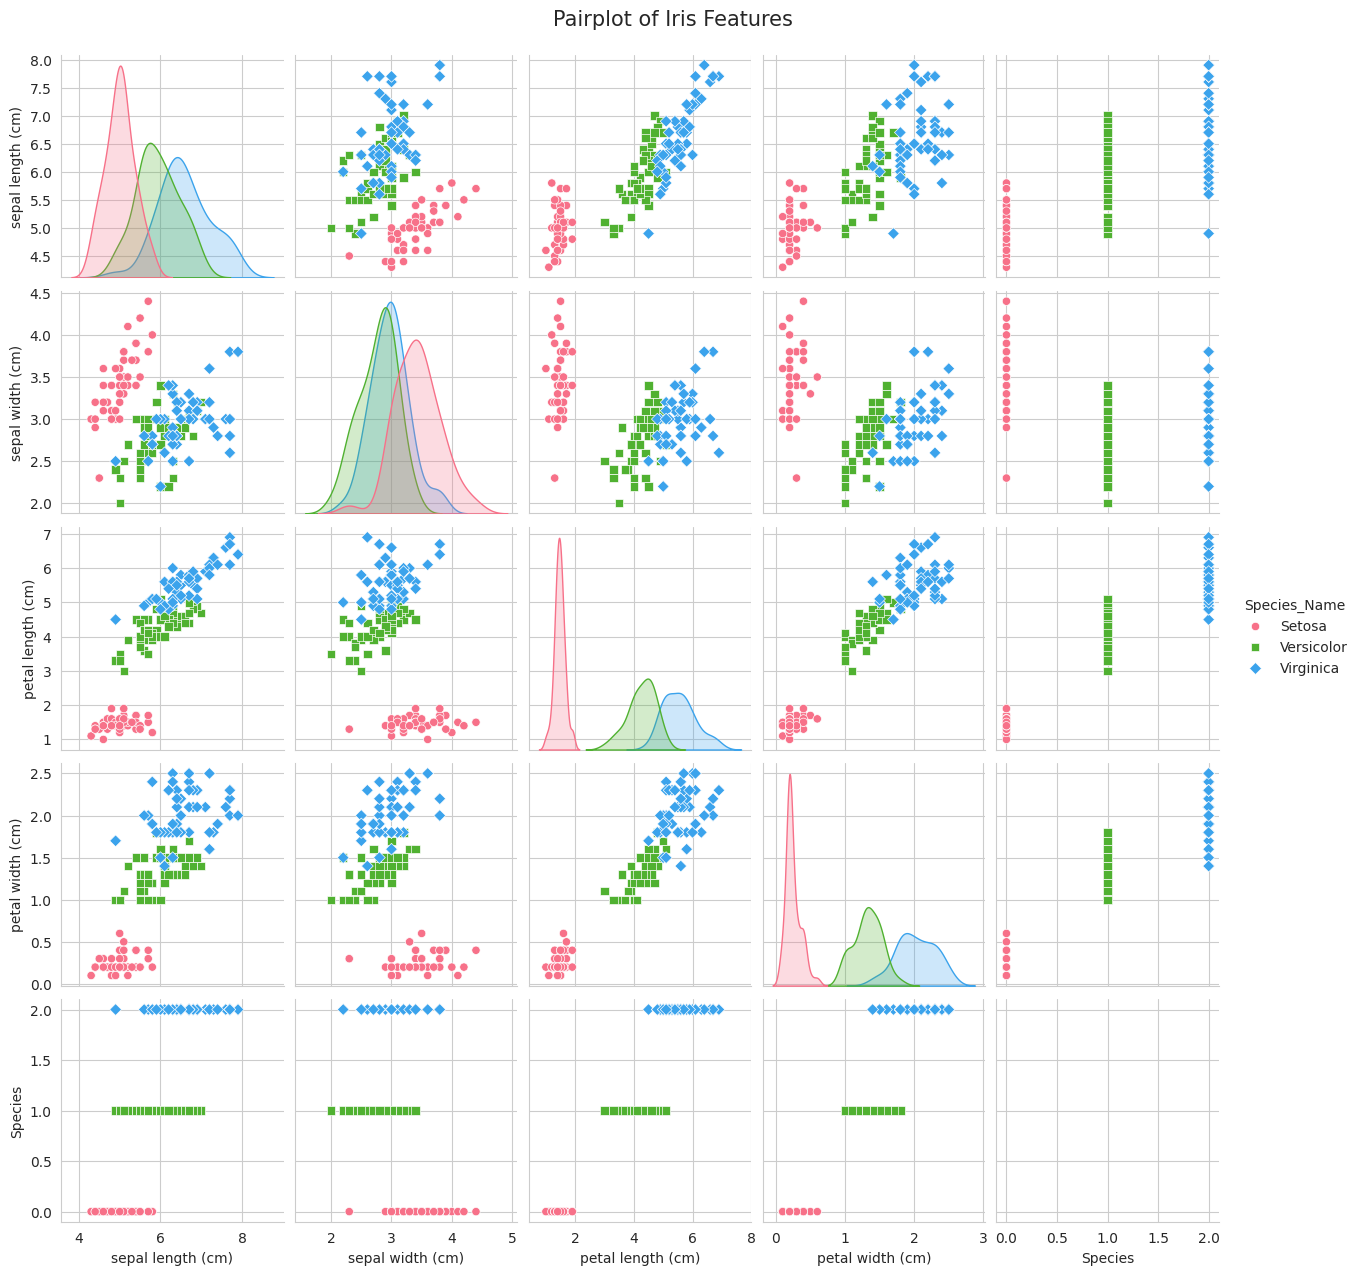

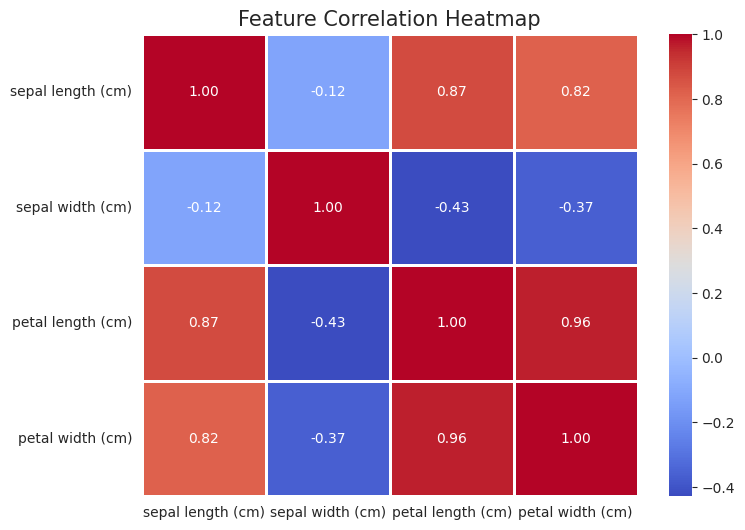

Data Scaled and Ready for Training!

 --- MACHINE LEARNING MODEL SHOWDOWN --- 

 1. Logistic Regression Accuracy: 100.00%
 2. Random Forest Accuracy: 100.00%
 3. Support Vector Machine Accuracy: 96.67%

 --- DETAILED REPORT FOR SVM (WINNER) --- 
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

print("Libraries Imported Successfully!\n")
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['Species'] = iris.target

df['Species_Name'] = df['Species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("Dataset Overview:")
print(df.head(), "\n")

print("Generating Beautiful Visualizations... (Please wait a second)")

sns.set_style("whitegrid")
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='Species_Name', palette='husl', markers=["o", "s", "D"])
plt.suptitle("Pairplot of Iris Features", y=1.02, fontsize=15)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.iloc[:, :-2].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=2)
plt.title("Feature Correlation Heatmap", fontsize=15)
plt.show()
X = df.drop(columns=['Species', 'Species_Name'])
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Scaled and Ready for Training!\n")

print(" --- MACHINE LEARNING MODEL SHOWDOWN --- \n")

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
log_acc = accuracy_score(y_test, log_model.predict(X_test_scaled))
print(f" 1. Logistic Regression Accuracy: {log_acc * 100:.2f}%")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test_scaled))
print(f" 2. Random Forest Accuracy: {rf_acc * 100:.2f}%")

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train)
svm_acc = accuracy_score(y_test, svm_model.predict(X_test_scaled))
print(f" 3. Support Vector Machine Accuracy: {svm_acc * 100:.2f}%\n")

print(" --- DETAILED REPORT FOR SVM (WINNER) --- ")
y_pred_best = svm_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))